# Predicción de Mortalidad y Natalidad en Argentina al 2050
## Universal Differential Equations (UDE) sobre datos demográficos 2012–2022

**Autores:** Gangui Matias.  

**Curso:** Datos, IA y Ecuaciones Diferenciales.

**Dataset:** [Nacimientos INDEC 2012-2022](https://datos.gob.ar/dataset/renaper-nacimientos-argentina) | [Mortalidad INDEC 1914–2023](https://datos.salud.gob.ar/dataset/serie-historica-de-defunciones-ocurridas-en-argentina-por-jurisdiccion) | [Migracion CEPALSTAT 1950 - 2022](https://statistics.cepal.org/portal/cepalstat/dashboard.html?indicator_id=33&area_id=400&lang=es)

Los Datasets utilizados en el proyecto han sido transformados, normalizados y unificados con respecto al análisis que buscamos realizar

---

## Introducción

Una **Universal Differential Equation (UDE)** es un sistema de ecuaciones diferenciales donde algunos términos, en lugar de ser funciones paramétricas fijas, son **redes neuronales**. Esto permite que la física o la lógica estructural del problema quede codificada en la ODE, mientras que los mecanismos desconocidos o complejos los aprende la red.

En demografía, la dinámica de una población satisface:

$$\frac{dP}{dt} = P(t) \cdot \left[ \underbrace{\beta(t;\,\theta_\beta)}_{\text{tasa de natalidad}} - \underbrace{\delta(t;\,\theta_\delta)}_{\text{tasa de mortalidad}} + \underbrace{\mu(t)}_{\text{tasa de migración neta}} \right]$$

Cada término tiene un rol distinto:

| Término | Naturaleza | Origen |
|---|---|---|
| $\beta(t;\theta_\beta)$ — natalidad | Red neuronal | Aprendida de datos INDEC |
| $\delta(t;\theta_\delta)$ — mortalidad | Red neuronal | Aprendida de datos INDEC |
| $\mu(t)$ — migración neta | Función conocida | Dataset CEPALSTAT 1950–2022 |

La estructura multiplicativa $P(t) \cdot [\cdot]$ es el **conocimiento físico**: el crecimiento es proporcional a la población existente (crecimiento de Malthus generalizado).  
Las funciones $\beta(t;\theta)$ y $\delta(t;\theta)$ son **redes neuronales** que aprenden la forma precisa de esas tasas a partir de los datos históricos.  
La migración $\mu(t)$ en cambio se trata como un término **conocido y explícito**, es decir que no hay nada que aprender, los datos de CEPALSTAT ya lo capturan.

> **¿Por qué UDE?**  
> Una UDE predice la *dinámica* (cómo cambia la población) respetando la estructura diferencial. Esto permite interpretar las tasas aprendidas.
> 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from scipy.integrate import solve_ivp
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint

from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

# Estilo de gráficos
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

## 2. Métricas Demográficas

Calculamos las tasas estandarizadas que permiten comparar provincias con poblaciones muy distintas.

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **TBN** - Tasa Bruta de Natalidad | $\frac{\text{nacimientos}}{P} \times 1000$ | Nacidos vivos por cada 1.000 habitantes |
| **TBM** - Tasa Bruta de Mortalidad | $\frac{\text{defunciones}}{P} \times 1000$ | Defunciones por cada 1.000 habitantes |
| **Crecimiento vegetativo** | $\text{nacimientos} - \text{defunciones}$ | Saldo natural absoluto |
| **Tasa de crecimiento vegetativo** | $\text{TBN} - \text{TBM}$ | Saldo natural por 1.000 hab. |
| **TGF** - Tasa Global de Fecundidad | (precalculada) | Hijos esperados por mujer en edad fértil |


In [ ]:
df_proyecto = pd.read_csv('datasets/df_proyecto.csv')
df_migracion = pd.read_csv('datasets/tasa_migracion_argentina.csv').set_index('anio')
df_migracion['migracion_pc'] = df_migracion['tasa_migracion_por_1000_hab'] / 1000  # por persona por año
df_proyecto.head()

,anio,provincia,nacimientos_cantidad,poblacion,tgf,defunciones,tbn,tbm,crecimiento_vegetativo,tasa_crecimiento
0,2012,buenos_aires,289720,16100397,2.570655,132349,17.994587,8.220232,157371,9.774355
1,2012,capital_federal,45013,3038860,2.116066,31560,14.812463,10.385473,13453,4.426989
2,2012,catamarca,6485,385408,2.403761,2260,16.826324,5.863916,4225,10.962409
3,2012,chaco,22829,1105280,2.950642,7128,20.654495,6.449045,15701,14.205450
4,2012,chubut,9725,534945,2.597063,3033,18.179439,5.669742,6692,12.509697


In [10]:
df_migracion

,tasa_migracion_por_1000_hab,migracion_pc
anio,,
1950,3.55,0.00355
1951,3.14,0.00314
1952,2.72,0.00272
1953,2.31,0.00231
1954,1.94,0.00194
...,...,...
2018,0.13,0.00013
2019,0.12,0.00012
2020,0.01,0.00001


## Análisis Exploratorio Nacional

Consolidamos la serie temporal nacional (suma de todas las provincias) para visualizar las tendencias estructurales y los shocks externos.

**Shocks esperados:**
- **2020–2021**: exceso de mortalidad por COVID-19 (visible en TBM)
- **2019–2022**: caída pronunciada de la TGF por debajo del umbral de reemplazo (2,1)


C:\Users\Matias\AppData\Local\Temp\ipykernel_12656\6207977.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['tgf'] * g['poblacion']).sum() / g['poblacion'].sum())


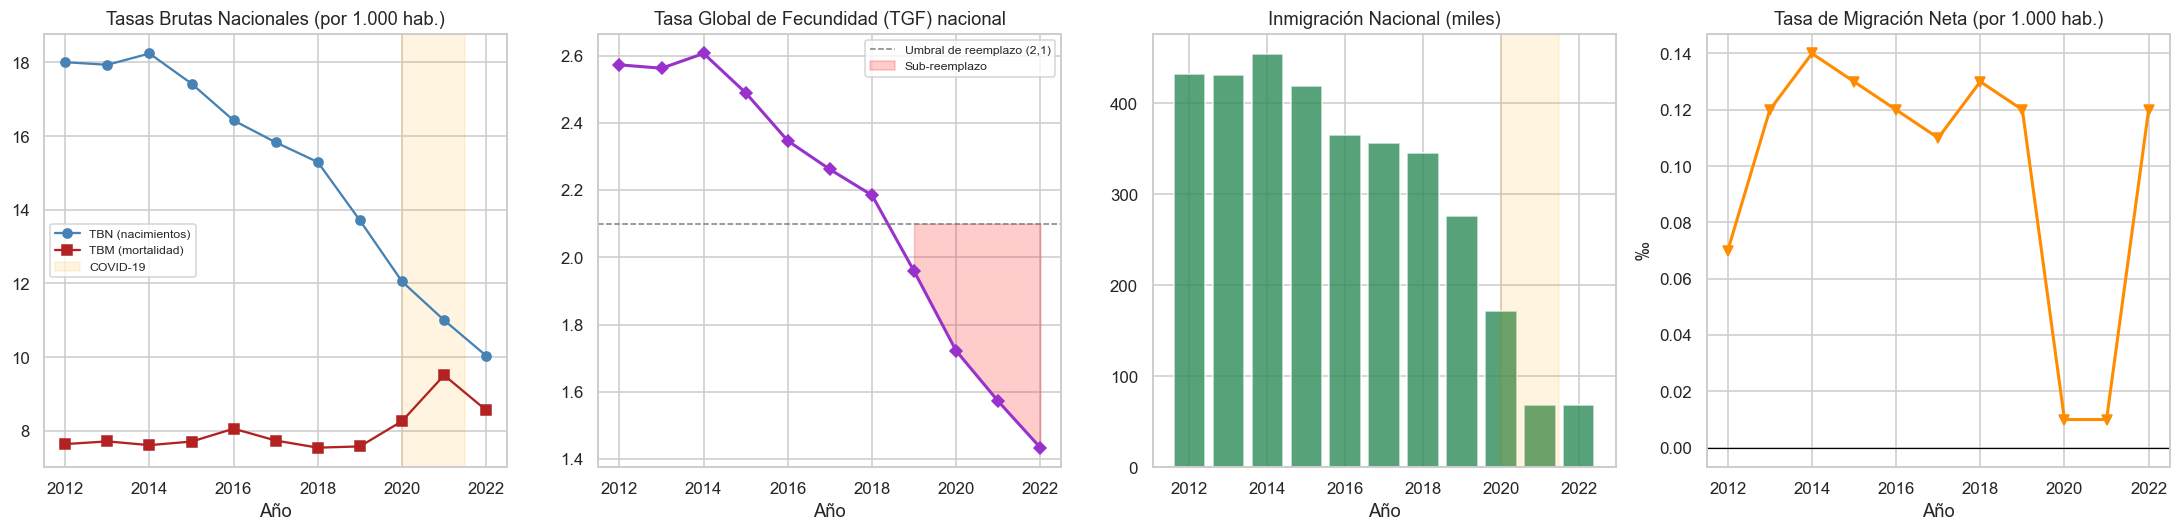


Argentina cruza el umbral de sub-reemplazo (TGF < 2.1) en 2019
Tasa de migración promedio 2012–2022: 0.098 ‰


In [3]:
# Agregación nacional
nac_nacional  = df_proyecto.groupby('anio')['nacimientos_cantidad'].sum()
mort_nacional = df_proyecto.groupby('anio')['defunciones'].sum()
pob_nacional  = df_proyecto.groupby('anio')['poblacion'].sum()

# TGF nacional ponderada por población provincial
tgf_nacional = (
    df_proyecto.groupby('anio')
    .apply(lambda g: (g['tgf'] * g['poblacion']).sum() / g['poblacion'].sum())
)

df_ude = pd.DataFrame({
    'nacimientos': nac_nacional,
    'mortalidad':  mort_nacional,
    'poblacion':   pob_nacional,
    'tgf':         tgf_nacional
}).dropna()

# Tasas nacionales
df_ude['tbn'] = df_ude['nacimientos'] / df_ude['poblacion'] * 1000
df_ude['tbm'] = df_ude['mortalidad']  / df_ude['poblacion'] * 1000

# Migración nacional per cápita (filtrada al período con datos demográficos)
df_ude = df_ude.join(df_migracion[['migracion_pc']], how='left')
df_ude['migracion_pc'] = df_ude['migracion_pc'].ffill()  # completar eventuales faltantes

# — Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# TBN y TBM
ax = axes[0]
ax.plot(df_ude.index, df_ude['tbn'], 'o-', color='steelblue',  label='TBN (nacimientos)')
ax.plot(df_ude.index, df_ude['tbm'], 's-', color='firebrick',  label='TBM (mortalidad)')
ax.axvspan(2020, 2021.5, alpha=0.12, color='orange', label='COVID-19')
ax.set_title('Tasas Brutas Nacionales (por 1.000 hab.)')
ax.set_xlabel('Año')
ax.legend(fontsize=8)

# TGF
ax = axes[1]
ax.plot(df_ude.index, df_ude['tgf'], 'D-', color='darkorchid', linewidth=2)
ax.axhline(2.1, color='gray', linestyle='--', linewidth=1, label='Umbral de reemplazo (2,1)')
ax.fill_between(df_ude.index, df_ude['tgf'], 2.1,
                where=(df_ude['tgf'] < 2.1), alpha=0.2, color='red', label='Sub-reemplazo')
ax.set_title('Tasa Global de Fecundidad (TGF) nacional')
ax.set_xlabel('Año')
ax.legend(fontsize=8)

# Inmigración absoluto
cv = df_ude['nacimientos'] - df_ude['mortalidad']
ax = axes[2]
ax.bar(df_ude.index, cv / 1000, color='seagreen', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvspan(2020, 2021.5, alpha=0.12, color='orange')
ax.set_title('Inmigración Nacional (miles)')
ax.set_xlabel('Año')

# Tasa de migración neta
ax = axes[3]
ax.plot(df_ude.index, df_ude['migracion_pc'] * 1000, 'v-', color='darkorange', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Tasa de Migración Neta (por 1.000 hab.)')
ax.set_xlabel('Año')
ax.set_ylabel('‰')

plt.tight_layout()
plt.show()

print("\nArgentina cruza el umbral de sub-reemplazo (TGF < 2.1) en", 
      df_ude[df_ude['tgf'] < 2.1].index[0])
print(f"Tasa de migración promedio 2012–2022: {df_ude['migracion_pc'].mean()*1000:.3f} ‰")


## 4. Modelo Clásico: ODE con Tasas Interpoladas

Antes de introducir las redes neuronales, construimos el modelo clásico. Este modelo sirve como **baseline** y demuestra la estructura diferencial correcta.

### Ecuación de Malthus generalizada

$$\frac{dP}{dt} = P(t) \cdot \left[ b(t) - d(t) + m(t) \right]$$

donde $b(t) = \text{TBN}(t)/1000$, $d(t) = \text{TBM}(t)/1000$ y $m(t) = \text{MIG}(t)/1000$ son las tasas per cápita por año.
  

```python
# b(t), d(t) y m(t) son tasas per cápita
dpdt = P[0] * (b_func(t) - d_func(t) + m_func(t))
```

---

## La conexión con Lotka-Volterra
Malthus es exactamente Lotka-Volterra sin depredador y con parámetros que varían. Lotka-Volterra, en cambio, requiere de dos poblaciones que se retroalimentan. En demografía de una sola nación no hay ese acoplamiento, pues la natalidad y mortalidad son tasas internas de la misma población, no dos especies compitiendo. La UDE extiende eso permitiendo que α (en nuestro caso β−δ + μ) sea una función del tiempo aprendida por una red, en lugar de una constante.

Para la dinámica total de una nación, Malthus (generalizado con UDE) es la elección correcta porque hay una sola entidad que evoluciona con tasas internas propias.

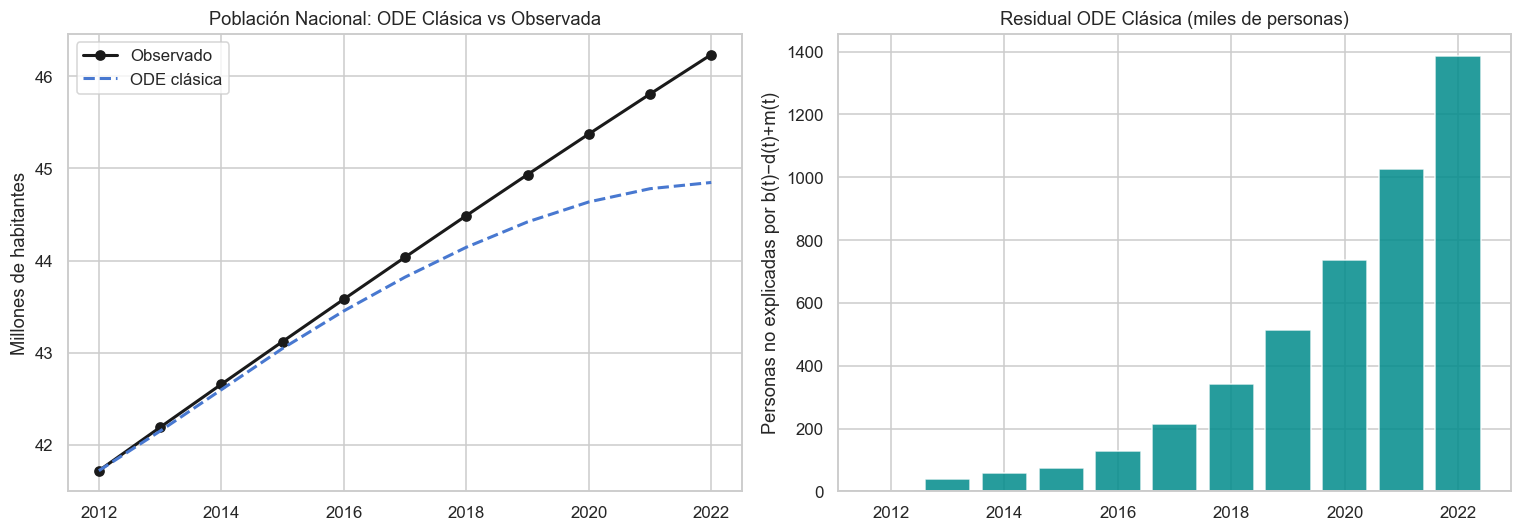

Residual promedio anual: 411.4 miles de personas
Residual total acumulado 2012–2022: 4.53 millones


In [4]:
t_data = df_ude.index.values.astype(float)

# Tasas per cápita por año
tbn_pc = df_ude['nacimientos'] / df_ude['poblacion']  # nacimientos por persona por año
tbm_pc = df_ude['mortalidad']  / df_ude['poblacion']  # muertes por persona por año
mig_pc = df_ude['migracion_pc']                        # migracion neta por persona por año

# Interpolación cúbica de las tasas observadas
b_func = interp1d(t_data, tbn_pc, kind='cubic', fill_value='extrapolate')
d_func = interp1d(t_data, tbm_pc, kind='cubic', fill_value='extrapolate')
m_func = interp1d(t_data, mig_pc, kind='cubic', fill_value='extrapolate')

def ode_clasica(t, P):
    """
    dP/dt = P(t) * [b(t) - d(t) + m(t)]

    P: vector de estado [P_actual]
    b, d: tasas de natalidad y mortalidad per cápita por año
    m:    tasa de migración neta per cápita por año (CEPALSTAT)
    """
    return [P[0] * (b_func(t) - d_func(t) + m_func(t))]

P0_clasica = [df_ude['poblacion'].iloc[0]]

sol = solve_ivp(
    ode_clasica,
    t_span=[t_data[0], t_data[-1]],
    y0=P0_clasica,
    t_eval=t_data,
    method='RK45'
)

# Residual = diferencia entre observado e integrado
residual_ode = df_ude['poblacion'].values - sol.y[0]

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(t_data, df_ude['poblacion'] / 1e6, 'ko-', label='Observado', linewidth=2)
ax.plot(t_data, sol.y[0] / 1e6, 'b--', label='ODE clásica', linewidth=2)
ax.set_title('Población Nacional: ODE Clásica vs Observada')
ax.set_ylabel('Millones de habitantes')
ax.legend()

ax = axes[1]
ax.bar(t_data, residual_ode / 1e3, color='darkcyan', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Residual ODE Clásica (miles de personas)')
ax.set_ylabel('Personas no explicadas por b(t)−d(t)+m(t)')

plt.tight_layout()
plt.show()

print(f"Residual promedio anual: {np.mean(residual_ode)/1e3:.1f} miles de personas")
print(f"Residual total acumulado 2012–2022: {np.sum(residual_ode[1:])/1e6:.2f} millones")


### ¿Qué observamos?

#### Leyenda
**Observado** - Son los datos reales del INDEC, la población que efectivamente tenía Argentina cada año, según proyecciones censales. Es la "realidad" contra la que comparamos el modelo.

**ODE Clásica** - Es la población que predice el modelo de Malthus con migración, integrando la ecuación diferencial:

$$\frac{dP}{dt} = P(t)\,[b(t) - d(t) + m(t)]$$


---




## Función de costo: MSE (Error Cuadrático Medio)

Utilizamos la función de costo basada en el error cuadrático medio (MSE), derivada de asumir que el ruido de las observaciones sigue una distribución gaussiana independiente e idénticamente distribuida:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N}\left(P_{obs}(t_i) - \hat{P}(t_i;\theta)\right)^2$$

**¿Por qué usar esta función?**
El MSE estándar trata los años del COVID igual que el resto, forzando a la red a aprender la anomalía como si fuera dinámica real. Con pesos podemos bajar la influencia de esos años.

In [5]:
#  α = tasa media de natalidad per cápita  (término lineal conocido)
#  γ = tasa media de mortalidad per cápita (término lineal conocido)
#  μ = tasa media de migración per cápita  (término lineal conocido)
#  nn(τ) = red neuronal que aprende la desviación temporal respecto a las medias


# Términos lineales conocidos (fijos, como α y γ en LV)
alpha = float(tbn_pc.mean())   # tasa base de natalidad
gamma = float(tbm_pc.mean())   # tasa base de mortalidad
mu    = float(mig_pc.mean())   # tasa base de migración

print(f"α (natalidad base):  {alpha*1000:.3f} ‰")
print(f"γ (mortalidad base): {gamma*1000:.3f} ‰")
print(f"μ (migración base):  {mu*1000:.3f} ‰")

# Red neuronal: R¹ → R¹  (entrada: τ, salida: corrección escalar)
nn_interaccion = nn.Sequential(
    nn.Linear(1, 16), nn.Tanh(),
    nn.Linear(16, 16), nn.Tanh(),
    nn.Linear(16, 1)           
)


# Normalización del tiempo: τ ∈ [0, 1]
t_min, t_max = t_data[0], t_data[-1]
t_norm = torch.tensor((t_data - t_min) / (t_max - t_min), dtype=torch.float32)

# Normalización de población
P_scale = float(df_ude['poblacion'].iloc[0])
P_obs   = torch.tensor(df_ude['poblacion'].values / P_scale, dtype=torch.float32)
P0      = P_obs[0:1].clone()

def ude_forward(tau, P):
    """
    dP/dt = P * (α - γ + μ) + nn(τ) * P
            ^^^^^^^^^^^^^^^^   ^^^^^^^^^^^^^^^^^^
            término lineal      interacción aprendida
            (natalidad,         (desviaciones temporales
            mortalidad,          no capturadas por medias)
            migración conocidos)
    """
    correccion = nn_interaccion(tau.reshape(1, 1)).squeeze()
    return P * ((alpha - gamma + mu) + correccion)

# Solución UDE antes de entrenar (pesos aleatorios — como PRETRAIN=false en Julia)
with torch.no_grad():
    P_antes = odeint(ude_forward, P0, t_norm, method='dopri5').squeeze().numpy() * P_scale


# Entrenamiento

optimizer = optim.Adam(nn_interaccion.parameters(), lr=1e-2)

N_EPOCHS = 3000
losses   = []

for epoch in range(N_EPOCHS + 1):
    optimizer.zero_grad()

    P_pred = odeint(ude_forward, P0, t_norm, method='dopri5')
    loss   = torch.mean((P_pred.squeeze() - P_obs) ** 2)

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"Época {epoch:5d} | Loss: {loss.item():.2e}")

# Solución UDE entrenada
with torch.no_grad():
    P_fit = odeint(ude_forward, P0, t_norm, method='dopri5').squeeze().numpy() * P_scale


α (natalidad base):  15.087 ‰
γ (mortalidad base): 7.992 ‰
μ (migración base):  0.098 ‰
Época     0 | Loss: 4.49e-03
Época   500 | Loss: 3.98e-10
Época  1000 | Loss: 3.77e-10
Época  1500 | Loss: 3.27e-10
Época  2000 | Loss: 2.97e-10
Época  2500 | Loss: 3.37e-10
Época  3000 | Loss: 5.99e-10


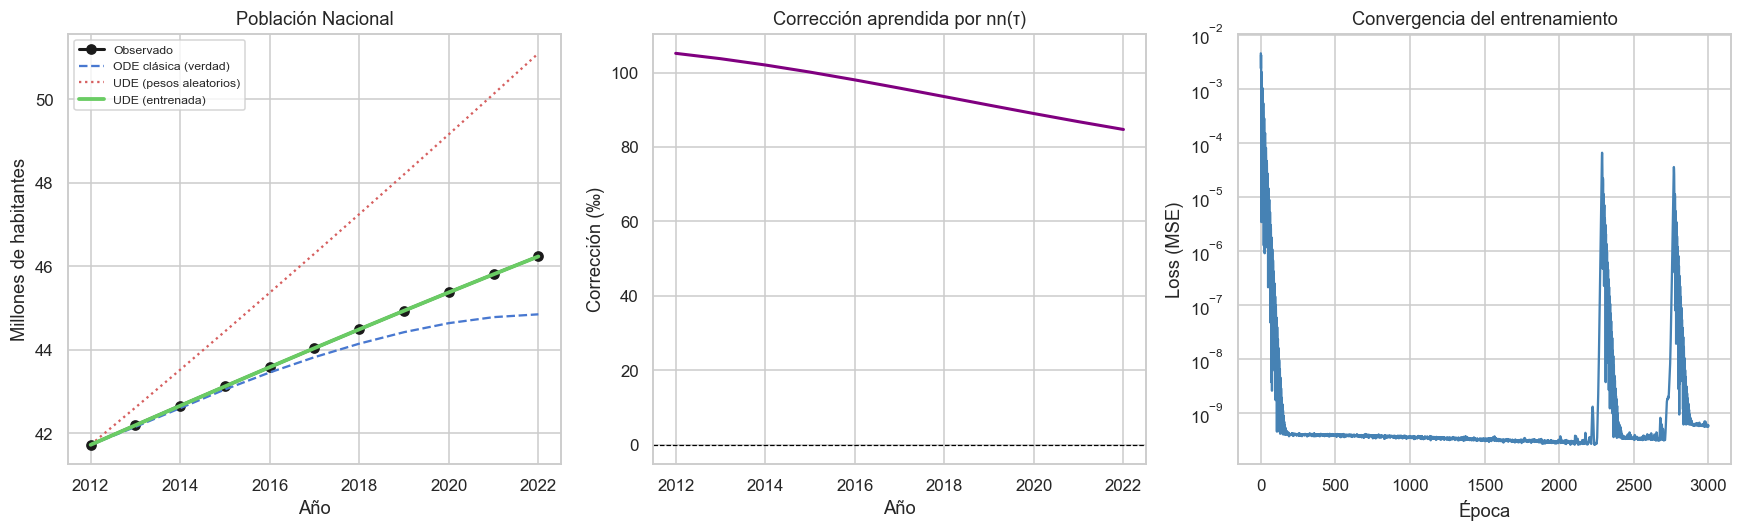

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Población: verdad vs UDE (antes y despues de entrenar)
ax = axes[0]
ax.plot(t_data, df_ude['poblacion'] / 1e6, 'ko-', lw=2, label='Observado')
ax.plot(t_data, sol.y[0] / 1e6, 'b--', lw=1.5, label='ODE clásica (verdad)')
ax.plot(t_data, P_antes / 1e6, 'r:', lw=1.5, label='UDE (pesos aleatorios)')
ax.plot(t_data, P_fit / 1e6,   'g-', lw=2.5, label='UDE (entrenada)')
ax.set_title('Población Nacional')
ax.set_ylabel('Millones de habitantes')
ax.set_xlabel('Año')
ax.legend(fontsize=8)

# Corrección aprendida por la red
ax = axes[1]
with torch.no_grad():
    corr = np.array([nn_interaccion(tau.reshape(1,1)).item() for tau in t_norm])
    
ax.plot(t_data, corr * 1000, 'purple', lw=2)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Corrección aprendida por nn(τ)')
ax.set_ylabel('Corrección (‰)')
ax.set_xlabel('Año')

# Curva de pérdida
ax = axes[2]
ax.semilogy(losses, color='steelblue', lw=1.5)
ax.set_title('Convergencia del entrenamiento')
ax.set_xlabel('Época')
ax.set_ylabel('Loss (MSE)')

plt.tight_layout()
plt.show()

### Gráfico 1 - Población Nacional
La UDE entrenada (verde) se superpone casi perfectamente con los datos observados (negro), mientras que la ODE clásica (azul) queda sistemáticamente por debajo. Esto confirma dos cosas:

- La red aprendió a capturar la dinámica real.
- Los pesos aleatorios (rojo punteado) producen una solución absurda, lo que muestra que el entrenamiento fue esencial y funcionó correctamente.

### Gráfico 2 - Corrección aprendida nn(τ)
La corrección es siempre positiva y decreciente. Esto se debe a que la red está compensando que α − γ (la diferencia entre las tasas medias fijas) subestima el crecimiento real. 

Notemos que la corrección nunca cruza cero, lo que significa que la población real creció siempre más rápido de lo que predice Malthus con tasas medias fijas.

### Gráfico 3 - Convergencia
La loss cae abruptamente en pocas épocas. La loss final es extremadamente baja, lo que valida el ajuste casi perfecto del gráfico 1.


---
## Estimemos para el año 2050


Vamos a querer estimar hasta 2050 basándonos en 3 posibles escenarios:
- **Escenario Optimista**: Corrección +10% (donde veríamos una mayor migración y una recuperación en la natalidad).
- **Escenario Base**: La tendencia pura de nuestra red neuronal actual.
- **Pesimista**: Corrección -25% (donde veríamos una menor migración y una caída en la fecundidad)

In [7]:
# Extrapolación al 2050

# Tiempo extendido hasta 2050
t_futuro = np.linspace(t_min, 2050, 300)
tau_futuro = torch.tensor((t_futuro - t_min) / (t_max - t_min), dtype=torch.float32)


# Escenarios posibles
escenarios = {
    'Optimista':  1.10,   # corrección +10% (más migración, recuperación natalidad)
    'Base':       1.00,   # tendencia pura de la red
    'Pesimista':  0.75,   # corrección −25% (menos migración, caída fecundidad)
}
colores = {'Optimista': 'seagreen', 'Base': 'steelblue', 'Pesimista': 'firebrick'}

predicciones = {}

for nombre, factor in escenarios.items():

    def ude_escenario(tau, P, f=factor):
        correccion = nn_interaccion(tau.reshape(1, 1)).squeeze()
        return P * ((alpha - gamma) + correccion * f)

    with torch.no_grad():
        P_esc = odeint(
            ude_escenario, P0, tau_futuro, method='dopri5'
        ).squeeze().numpy() * P_scale

    predicciones[nombre] = P_esc

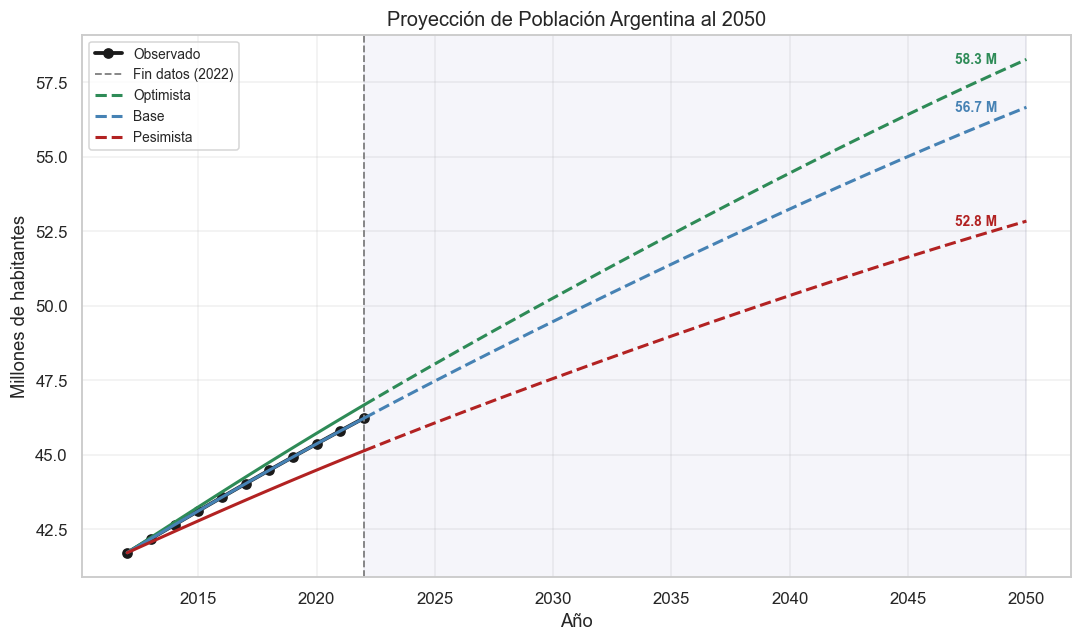

In [8]:
# Visualización - Solo Proyección de Población

idx_fin_datos = np.searchsorted(t_futuro, t_max)

# Cambiamos a 1 solo gráfico (1 fila, 1 columna)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Datos observados
ax.plot(t_data, df_ude['poblacion'] / 1e6, 'ko-', lw=2.5, ms=6, label='Observado')

# Línea de fin de datos
ax.axvline(t_max, color='gray', ls='--', lw=1.2, label='Fin datos (2022)')
ax.axvspan(t_max, 2050, alpha=0.04, color='navy')

# Escenarios
for nombre, pob in predicciones.items():
    # Tramo histórico (fit)
    ax.plot(t_futuro[:idx_fin_datos+1], pob[:idx_fin_datos+1] / 1e6,
            color=colores[nombre], lw=2)
    # Tramo extrapolado
    ax.plot(t_futuro[idx_fin_datos:], pob[idx_fin_datos:] / 1e6,
            color=colores[nombre], lw=2, ls='--', label=nombre)
    # Valor final
    ax.annotate(f'{pob[-1]/1e6:.1f} M',
                xy=(2050, pob[-1]/1e6),
                xytext=(2047, pob[-1]/1e6),
                fontsize=9, color=colores[nombre], va='center', fontweight='bold')

ax.set_title('Proyección de Población Argentina al 2050', fontsize=13)
ax.set_ylabel('Millones de habitantes')
ax.set_xlabel('Año')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Tabla resumen

pob_2022 = df_ude['poblacion'].iloc[-1]

print("=" * 52)
print("  PREDICCIONES PARA 2050 — UDE Demográfica")
print("=" * 52)
print(f"  Población observada 2022: {pob_2022/1e6:.2f} M")
print("-" * 52)
print(f"  {'Escenario':<12} {'Pob. 2050':>10}  {'Cambio':>10}  {'Factor nn':>10}")
print("-" * 52)
for nombre, factor in escenarios.items():
    pob_2050 = predicciones[nombre][-1]
    cambio   = (pob_2050 - pob_2022) / pob_2022 * 100
    print(f"  {nombre:<12} {pob_2050/1e6:>8.2f} M  {cambio:>+9.1f}%  {factor:>10.2f}x")
print("=" * 52)

  PREDICCIONES PARA 2050 — UDE Demográfica
  Población observada 2022: 46.23 M
----------------------------------------------------
  Escenario     Pob. 2050      Cambio   Factor nn
----------------------------------------------------
  Optimista       58.27 M      +26.0%        1.10x
  Base            56.66 M      +22.6%        1.00x
  Pesimista       52.84 M      +14.3%        0.75x


## Conclusión

Nuestro primer análisis muestra una clara desaceleración en el crecimiento poblacional en Argentina. 
Argentina cruzó el umbral de sub-reemplazo en 2019 y no se observan indicios de reversión (la TGF sigue cayendo), además la edad mediana proyectada por las Naciones Unidas sigue incrementando año tras año (ver [Infobae](https://www.infobae.com/realidad-aumentada/2024/08/12/asi-sera-la-poblacion-argentina-en-2100-cuantos-habitantes-de-que-edad-y-con-que-nivel-de-estudios/)), reflejando un envejecimiento progresivo constante de la población.

Nuestro modelo UDE muestra un crecimiento moderado hasta 2050, sin indicios de una fuerte desaceleración. Éste resultado es consistente con fuentes externas como [Infobae](https://www.infobae.com/realidad-aumentada/2024/08/12/asi-sera-la-poblacion-argentina-en-2100-cuantos-habitantes-de-que-edad-y-con-que-nivel-de-estudios/) pero a la vez inconsistente con otras como [Argendata](https://argendata.fund.ar/topico/poblacion/), que marcan una desaceleración de la población más inmediata.

El modelo no predice con precisión cuándo se alcanzará el pico poblacional, pero las condiciones para que ocurra dentro del siglo están instaladas. La pregunta ya no es **si Argentina llega a ese pico, sino cuándo**, y dependerá principalmente de si la TGF logra estabilizarse o continúa su descenso.